# FD001 Advanced Machine Learning for Remaining Useful Life Prediction

**Student:** Ivan Da Silva  
**Course:** AAI-501-01 Introduction to Artificial Intelligence and Machine Learning  
**Responsibility:** Advanced ML and Model Comparison

This notebook continues the work from notebooks 01 and 02. Russell prepared and explored the FD001 data. Mina trained the traditional machine learning baselines. My part is to train XGBoost, tune its hyperparameters, study feature importance, and compare XGBoost with the baseline models.

This project uses only FD001. It contains 100 training engines, 100 test engines, one sea-level operating condition, and one HPC degradation fault mode. The results cannot represent all C-MAPSS conditions or fan degradation. Testing FD002, FD003, or FD004 would be future work.

## 1. Problem and Evaluation Plan

The goal is to predict Remaining Useful Life (RUL), measured in engine cycles. I will answer this question:

**Can a tuned XGBoost model improve RUL prediction compared with Linear Regression, Random Forest, and Gradient Boosting?**

For a fair comparison, I used the same FD001 data, 18 predictors, engine-level split, RUL cap of 125 cycles, and test-engine endpoints used in Mina's notebook.

RMSE ((Root Mean Squared Error) is the main metric because it gives a larger penalty to large prediction errors. MAE (Mean Absolute Error)shows the average absolute error in cycles. R² (R-Squared )shows how much variation the model explains. The official test data is not used during hyperparameter tuning.

## 2. Setup

The next cell imports the libraries and prints their versions. The fixed random seed helps make the results reproducible.

In [78]:
from pathlib import Path
import platform
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sklearn
import xgboost

from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV, GroupKFold, train_test_split
from xgboost import XGBRegressor

RANDOM_STATE = 42
RUL_CAP = 125

np.random.seed(RANDOM_STATE)
warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

print(f"Python: {platform.python_version()}")
print(f"pandas: {pd.__version__}")
print(f"scikit-learn: {sklearn.__version__}")
print(f"XGBoost: {xgboost.__version__}")

Python: 3.14.5
pandas: 3.0.5
scikit-learn: 1.9.0
XGBoost: 3.3.0


## 3. Load Project Files

All files are loaded from this GitHub repository. The notebook does not download another copy of the dataset and does not depend on Google Colab folders.

Notebook 01 creates the processed training file. Notebook 02 creates `../reports/baseline_model_comparison.csv`, which contains Mina's traditional-model results.

In [79]:
RAW_DIR = Path("../datasets/raw/CMAPSSData")
TEST_PATH = RAW_DIR / "test_FD001.txt"
TEST_RUL_PATH = RAW_DIR / "RUL_FD001.txt"
PROCESSED_PATH = Path(
    "../datasets/processed/fd001_train_with_rul.csv"
)
BASELINE_RESULTS_PATH = Path(
    "../reports/baseline_model_comparison.csv"
)

required_paths = [
    PROCESSED_PATH,
    TEST_PATH,
    TEST_RUL_PATH,
    BASELINE_RESULTS_PATH,
]
missing_paths = [path for path in required_paths if not path.exists()]
if missing_paths:
    missing_text = "\n".join(str(path) for path in missing_paths)
    raise FileNotFoundError(f"Required project files are missing:\n{missing_text}")

print(f"Processed training data: {PROCESSED_PATH}")
print(f"Baseline results: {BASELINE_RESULTS_PATH}")

Processed training data: ../datasets/processed/fd001_train_with_rul.csv
Baseline results: ../reports/baseline_model_comparison.csv


In [80]:
column_names = (
    ["engine_id", "cycle", "setting1", "setting2", "setting3"]
    + [f"sensor{i}" for i in range(1, 22)]
)

train_df = pd.read_csv(PROCESSED_PATH)
test_df = pd.read_csv(TEST_PATH, sep=r"\s+", header=None, names=column_names)
test_rul_df = pd.read_csv(
    TEST_RUL_PATH,
    sep=r"\s+",
    header=None,
    names=["RUL"],
)
test_rul_df["engine_id"] = np.arange(1, len(test_rul_df) + 1)

print(f"Training shape: {train_df.shape}")
print(f"Test trajectory shape: {test_df.shape}")
print(f"Official test labels: {test_rul_df.shape}")
train_df.head()

Training shape: (20631, 28)
Test trajectory shape: (13096, 26)
Official test labels: (100, 2)


,engine_id,cycle,setting1,setting2,setting3,sensor1,sensor2,sensor3,sensor4,sensor5,...,sensor14,sensor15,sensor16,sensor17,sensor18,sensor19,sensor20,sensor21,max_cycle,RUL
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190,192,191
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236,192,190
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442,192,189
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739,192,188
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044,192,187


## 4. Check the Data from Notebook 01

The code checks the expected FD001 structure before modeling. `RUL_bin` may appear in the processed file because notebook 01 uses it for an EDA chart. It is not a model feature and is removed from the modeling copy below.

This prevents accidental target leakage while allowing the current processed file to run safely.

In [81]:
required_train_columns = column_names + ["max_cycle", "RUL"]
missing_columns = set(required_train_columns).difference(train_df.columns)

assert not missing_columns, f"Missing columns: {sorted(missing_columns)}"
assert len(train_df) == 20631, "Unexpected FD001 training row count."
assert train_df["engine_id"].nunique() == 100, "Expected 100 engines."
assert not train_df.duplicated(["engine_id", "cycle"]).any()
assert not train_df[required_train_columns].isna().any().any()
assert (train_df["RUL"] >= 0).all()
assert train_df.groupby("engine_id")["RUL"].min().eq(0).all()
assert len(test_rul_df) == test_df["engine_id"].nunique() == 100

extra_columns = sorted(set(train_df.columns) - set(required_train_columns))
modeling_df = train_df[required_train_columns].copy()

print("All data checks passed.")
if extra_columns:
    print(f"EDA-only columns ignored by the model: {extra_columns}")
else:
    print("No extra EDA columns were found.")

All data checks passed.
No extra EDA columns were found.


## 5. Prepare the Shared Features and Engine Split

The target is clipped at 125 cycles to match Mina's experiment. Six constant sensors are removed. The remaining predictors are three operating settings and 15 sensors.

The split is completed by engine, not by individual rows. This keeps all cycles from one engine in the same partition and prevents leakage between training and validation data.

In [82]:
constant_sensors = [
    "sensor1",
    "sensor5",
    "sensor10",
    "sensor16",
    "sensor18",
    "sensor19",
]
setting_columns = ["setting1", "setting2", "setting3"]
sensor_columns = [
    column
    for column in column_names
    if column.startswith("sensor") and column not in constant_sensors
]
feature_columns = setting_columns + sensor_columns

modeling_df["RUL_clipped"] = modeling_df["RUL"].clip(upper=RUL_CAP)

engine_ids = np.sort(modeling_df["engine_id"].unique())
train_ids, validation_ids = train_test_split(
    engine_ids,
    test_size=0.20,
    random_state=RANDOM_STATE,
)

development_df = modeling_df[modeling_df["engine_id"].isin(train_ids)].copy()
validation_df = modeling_df[
    modeling_df["engine_id"].isin(validation_ids)
].copy()

X_train = development_df[feature_columns]
y_train = development_df["RUL_clipped"]
train_groups = development_df["engine_id"]

X_validation = validation_df[feature_columns]
y_validation = validation_df["RUL_clipped"]

assert set(train_ids).isdisjoint(validation_ids)
assert len(train_ids) == 80
assert len(validation_ids) == 20
assert len(feature_columns) == 18

print(f"Training engines: {len(train_ids)}; rows: {len(X_train):,}")
print(
    f"Validation engines: {len(validation_ids)}; "
    f"rows: {len(X_validation):,}"
)
print(f"Predictors: {len(feature_columns)}")
print(feature_columns)

Training engines: 80; rows: 16,561
Validation engines: 20; rows: 4,070
Predictors: 18
['setting1', 'setting2', 'setting3', 'sensor2', 'sensor3', 'sensor4', 'sensor6', 'sensor7', 'sensor8', 'sensor9', 'sensor11', 'sensor12', 'sensor13', 'sensor14', 'sensor15', 'sensor17', 'sensor20', 'sensor21']


In [83]:
test_last_cycle = (
    test_df.sort_values(["engine_id", "cycle"])
    .groupby("engine_id", as_index=False)
    .tail(1)
    .reset_index(drop=True)
    .merge(test_rul_df, on="engine_id", how="left", validate="one_to_one")
)
test_last_cycle["RUL_clipped"] = test_last_cycle["RUL"].clip(upper=RUL_CAP)

X_test = test_last_cycle[feature_columns]
y_test = test_last_cycle["RUL_clipped"]
y_test_uncapped = test_last_cycle["RUL"]

assert len(X_test) == 100
assert not test_last_cycle["RUL"].isna().any()

test_last_cycle[["engine_id", "cycle", "RUL", "RUL_clipped"]].head()

,engine_id,cycle,RUL,RUL_clipped
0,1,31,112,112
1,2,49,98,98
2,3,126,69,69
3,4,106,82,82
4,5,98,91,91


## 6. Load Mina's Baseline Results

Mina already trained Linear Regression, Random Forest, and Gradient Boosting. I loaded her saved comparison table instead of training the same models again. This keeps the team responsibilities clear and gives XGBoost the same baseline targets to beat.

In [84]:
# load baseline results fron Mina's results
baseline_results_df = pd.read_csv(BASELINE_RESULTS_PATH)
baseline_results_df = baseline_results_df.rename(
    columns={
        "Val_RMSE": "Validation_RMSE",
        "Val_MAE": "Validation_MAE",
        "Val_R2": "Validation_R2",
    }
)

expected_metric_columns = {
    "Model",
    "Validation_RMSE",
    "Validation_MAE",
    "Validation_R2",
    "Test_RMSE",
    "Test_MAE",
    "Test_R2",
}
missing_metric_columns = expected_metric_columns.difference(
    baseline_results_df.columns
)
assert not missing_metric_columns, (
    f"Baseline report is missing: {sorted(missing_metric_columns)}"
)

baseline_results_df = baseline_results_df[
    [
        "Model",
        "Validation_RMSE",
        "Validation_MAE",
        "Validation_R2",
        "Test_RMSE",
        "Test_MAE",
        "Test_R2",
    ]
].copy()

baseline_results_df.round(3)

,Model,Validation_RMSE,Validation_MAE,Validation_R2,Test_RMSE,Test_MAE,Test_R2
0,Random Forest,17.012,12.406,0.834,17.044,11.891,0.819
1,Gradient Boosting,17.063,12.542,0.833,17.455,11.767,0.810
2,Linear Regression,20.411,16.484,0.761,20.794,16.567,0.731


## 7. Train an Initial XGBoost Model

XGBoost builds a sequence of decision trees. Each new tree tries to correct errors from the earlier trees. The initial model uses reasonable starting values before tuning.

Tree models do not require feature scaling, so XGBoost uses the original sensor and setting values.

In [85]:
def regression_metrics(actual, predicted):
    return {
        "RMSE": mean_squared_error(actual, predicted) ** 0.5,
        "MAE": mean_absolute_error(actual, predicted),
        "R2": r2_score(actual, predicted),
    }


def evaluate_model(model, features, target):
    predictions = model.predict(features)
    return regression_metrics(target, predictions), predictions


initial_xgb = XGBRegressor(
    objective="reg:squarederror",
    n_estimators=200,
    max_depth=3,
    learning_rate=0.10,
    subsample=0.80,
    colsample_bytree=0.80,
    reg_lambda=1.0,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    tree_method="hist",
)
initial_xgb.fit(X_train, y_train)

initial_validation_metrics, initial_validation_predictions = evaluate_model(
    initial_xgb,
    X_validation,
    y_validation,
)
initial_test_metrics, initial_test_predictions = evaluate_model(
    initial_xgb,
    X_test,
    y_test,
)

pd.DataFrame(
    [
        {"Partition": "Validation", **initial_validation_metrics},
        {"Partition": "Official test", **initial_test_metrics},
    ]
).round(3)

,Partition,RMSE,MAE,R2
0,Validation,16.849,12.323,0.837
1,Official test,16.915,11.729,0.822


## 8. Tune the XGBoost Hyperparameters

I tuned three hyperparameters covered in the tree-based modeling material:

- `n_estimators`: number of trees;
- `max_depth`: maximum depth of each tree;
- `learning_rate`: contribution made by each new tree.

`GroupKFold` keeps each engine inside one cross-validation fold. The grid search uses only the 80 development engines. The 20 validation engines and 100 official test engines are not used to choose the hyperparameters.

In [86]:
tuning_model = XGBRegressor(
    objective="reg:squarederror",
    subsample=0.80,
    colsample_bytree=0.80,
    reg_lambda=1.0,
    random_state=RANDOM_STATE,
    n_jobs=1,
    tree_method="hist",
)

parameter_grid = {
    "n_estimators": [200, 400],
    "max_depth": [2, 3, 4],
    "learning_rate": [0.03, 0.05, 0.10],
}

group_cv = GroupKFold(n_splits=3)
grid_search = GridSearchCV(
    estimator=tuning_model,
    param_grid=parameter_grid,
    scoring="neg_root_mean_squared_error",
    cv=group_cv,
    refit=True,
    n_jobs=1,
    verbose=1,
    return_train_score=True,
)

grid_search.fit(X_train, y_train, groups=train_groups)

print(f"Best cross-validation RMSE: {-grid_search.best_score_:.3f}")
print("Best hyperparameters:")
print(grid_search.best_params_)

Fitting 3 folds for each of 18 candidates, totalling 54 fits
Best cross-validation RMSE: 18.952
Best hyperparameters:
{'learning_rate': 0.03, 'max_depth': 4, 'n_estimators': 200}


In [87]:
cv_results_df = pd.DataFrame(grid_search.cv_results_)
cv_summary = (
    cv_results_df[
        [
            "param_n_estimators",
            "param_max_depth",
            "param_learning_rate",
            "mean_train_score",
            "mean_test_score",
            "std_test_score",
            "rank_test_score",
        ]
    ]
    .assign(
        Mean_Train_RMSE=lambda frame: -frame["mean_train_score"],
        Mean_CV_RMSE=lambda frame: -frame["mean_test_score"],
    )
    .sort_values("rank_test_score")
)

cv_summary[
    [
        "rank_test_score",
        "param_n_estimators",
        "param_max_depth",
        "param_learning_rate",
        "Mean_Train_RMSE",
        "Mean_CV_RMSE",
        "std_test_score",
    ]
].head(10).round(3)

,rank_test_score,param_n_estimators,param_max_depth,param_learning_rate,Mean_Train_RMSE,Mean_CV_RMSE,std_test_score
4,1,200,4,0.03,17.097,18.952,1.050
5,2,400,4,0.03,16.310,18.973,1.092
10,3,200,4,0.05,16.604,18.987,1.109
3,4,400,3,0.03,17.380,19.047,1.069
9,5,400,3,0.05,16.917,19.060,1.093
8,6,200,3,0.05,17.531,19.062,1.078
11,7,400,4,0.05,15.454,19.063,1.116
2,8,200,3,0.03,17.860,19.112,0.977
14,9,200,3,0.10,16.967,19.141,1.071
16,10,200,4,0.10,15.559,19.162,1.101


## 9. Evaluate and Compare the Models

The best XGBoost model from cross-validation is evaluated on the validation engines and official test endpoints. I then compared the initial and tuned XGBoost models with Mina's three baseline models.

All values in the main comparison use RUL clipped at 125 cycles.

In [88]:
tuned_xgb = grid_search.best_estimator_
tuned_validation_metrics, tuned_validation_predictions = evaluate_model(
    tuned_xgb,
    X_validation,
    y_validation,
)
tuned_test_metrics, tuned_test_predictions = evaluate_model(
    tuned_xgb,
    X_test,
    y_test,
)

xgb_results_df = pd.DataFrame(
    [
        {
            "Model": "Initial XGBoost",
            "Validation_RMSE": initial_validation_metrics["RMSE"],
            "Validation_MAE": initial_validation_metrics["MAE"],
            "Validation_R2": initial_validation_metrics["R2"],
            "Test_RMSE": initial_test_metrics["RMSE"],
            "Test_MAE": initial_test_metrics["MAE"],
            "Test_R2": initial_test_metrics["R2"],
        },
        {
            "Model": "Tuned XGBoost",
            "Validation_RMSE": tuned_validation_metrics["RMSE"],
            "Validation_MAE": tuned_validation_metrics["MAE"],
            "Validation_R2": tuned_validation_metrics["R2"],
            "Test_RMSE": tuned_test_metrics["RMSE"],
            "Test_MAE": tuned_test_metrics["MAE"],
            "Test_R2": tuned_test_metrics["R2"],
        },
    ]
)

comparison_df = (
    pd.concat([baseline_results_df, xgb_results_df], ignore_index=True)
    .sort_values("Test_RMSE")
    .reset_index(drop=True)
)

comparison_df.round(3)

,Model,Validation_RMSE,Validation_MAE,Validation_R2,Test_RMSE,Test_MAE,Test_R2
0,Tuned XGBoost,16.881,12.390,0.836,16.843,11.614,0.823
1,Initial XGBoost,16.849,12.323,0.837,16.915,11.729,0.822
2,Random Forest,17.012,12.406,0.834,17.044,11.891,0.819
3,Gradient Boosting,17.063,12.542,0.833,17.455,11.767,0.810
4,Linear Regression,20.411,16.484,0.761,20.794,16.567,0.731


Tuned XGBoost reduced test RMSE by 0.201 cycles (1.18%) relative to the strongest baseline.


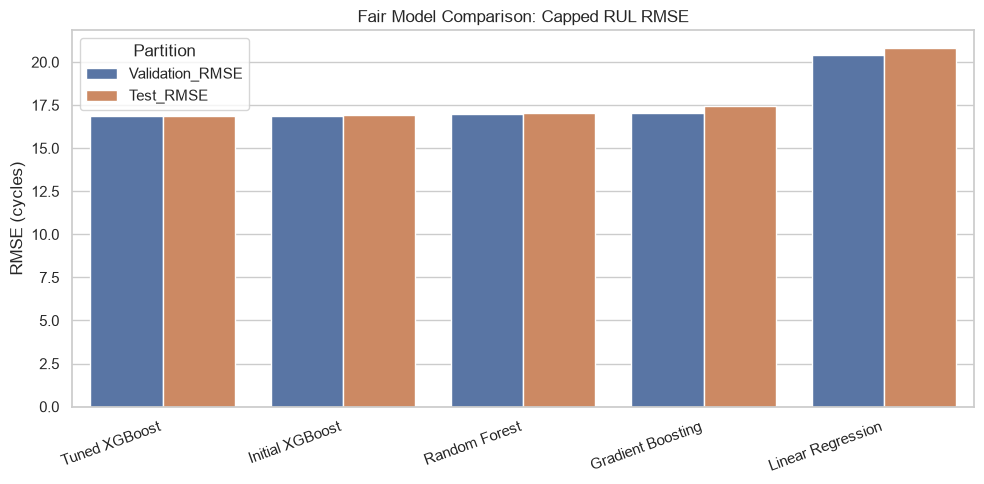

In [89]:
best_baseline_rmse = baseline_results_df["Test_RMSE"].min()
tuned_rmse = tuned_test_metrics["RMSE"]
rmse_change = best_baseline_rmse - tuned_rmse
percent_change = 100 * rmse_change / best_baseline_rmse

if rmse_change > 0:
    comparison_statement = (
        f"Tuned XGBoost reduced test RMSE by {rmse_change:.3f} cycles "
        f"({percent_change:.2f}%) relative to the strongest baseline."
    )
elif rmse_change < 0:
    comparison_statement = (
        f"Tuned XGBoost test RMSE was {-rmse_change:.3f} cycles higher "
        f"than the strongest baseline."
    )
else:
    comparison_statement = "Tuned XGBoost tied the strongest baseline."

print(comparison_statement)

plot_df = comparison_df.melt(
    id_vars="Model",
    value_vars=["Validation_RMSE", "Test_RMSE"],
    var_name="Partition",
    value_name="RMSE",
)

plt.figure(figsize=(10, 5))
sns.barplot(data=plot_df, x="Model", y="RMSE", hue="Partition")
plt.title("Fair Model Comparison: Capped RUL RMSE")
plt.xlabel("")
plt.ylabel("RMSE (cycles)")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

## 10. Review Errors by RUL Range

One overall metric can hide where a model has difficulty. I grouped the official test engines by their actual RUL. Errors near the end of engine life are important because those engines may need maintenance sooner.

A positive residual means the model predicted too few remaining cycles. A negative residual means the model predicted too many remaining cycles.

In [90]:
prediction_df = test_last_cycle[
    ["engine_id", "cycle", "RUL", "RUL_clipped"]
].copy()
prediction_df["Predicted_RUL"] = tuned_test_predictions
prediction_df["Residual"] = (
    prediction_df["RUL_clipped"] - prediction_df["Predicted_RUL"]
)
prediction_df["Absolute_Error"] = prediction_df["Residual"].abs()
prediction_df["RUL_Range"] = pd.cut(
    prediction_df["RUL_clipped"],
    bins=[-1, 25, 50, 100, RUL_CAP],
    labels=["0–25", "26–50", "51–100", "101–125"],
)

range_results = (
    prediction_df.groupby("RUL_Range", observed=False)
    .agg(
        Engines=("engine_id", "count"),
        MAE=("Absolute_Error", "mean"),
        Median_AE=("Absolute_Error", "median"),
        Mean_Residual=("Residual", "mean"),
    )
    .reset_index()
)
range_results.round(3)

,RUL_Range,Engines,MAE,Median_AE,Mean_Residual
0,0–25,19,9.614,4.064,-7.764
1,26–50,14,10.118,4.571,-7.942
2,51–100,34,15.984,11.252,-10.369
3,101–125,33,8.899,6.152,5.770


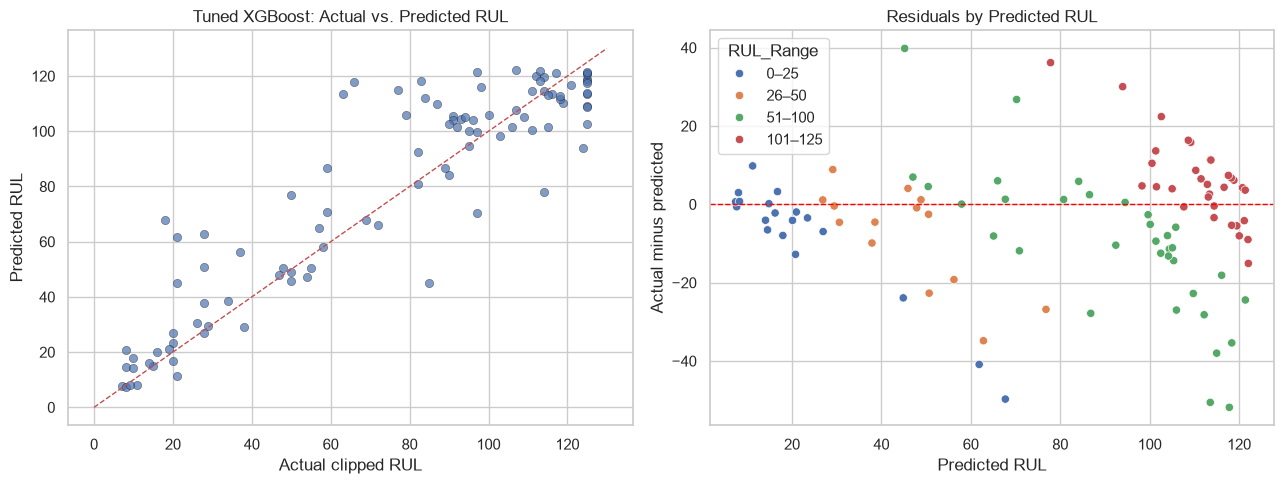

In [91]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

plot_limit = max(
    prediction_df["RUL_clipped"].max(),
    prediction_df["Predicted_RUL"].max(),
) + 5
axes[0].scatter(
    prediction_df["RUL_clipped"],
    prediction_df["Predicted_RUL"],
    alpha=0.70,
    edgecolor="black",
    linewidth=0.3,
)
axes[0].plot([0, plot_limit], [0, plot_limit], "r--", linewidth=1)
axes[0].set_title("Tuned XGBoost: Actual vs. Predicted RUL")
axes[0].set_xlabel("Actual clipped RUL")
axes[0].set_ylabel("Predicted RUL")

sns.scatterplot(
    data=prediction_df,
    x="Predicted_RUL",
    y="Residual",
    hue="RUL_Range",
    ax=axes[1],
)
axes[1].axhline(0, color="red", linestyle="--", linewidth=1)
axes[1].set_title("Residuals by Predicted RUL")
axes[1].set_xlabel("Predicted RUL")
axes[1].set_ylabel("Actual minus predicted")

plt.tight_layout()
plt.show()

## 11. Feature Importance

The built-in XGBoost importance shows which features the trees used most often to improve predictions. Permutation importance gives a second view by measuring how much validation performance changes after one feature is shuffled.

Feature importance helps explain model behavior, but it does not prove that a sensor causes engine degradation.

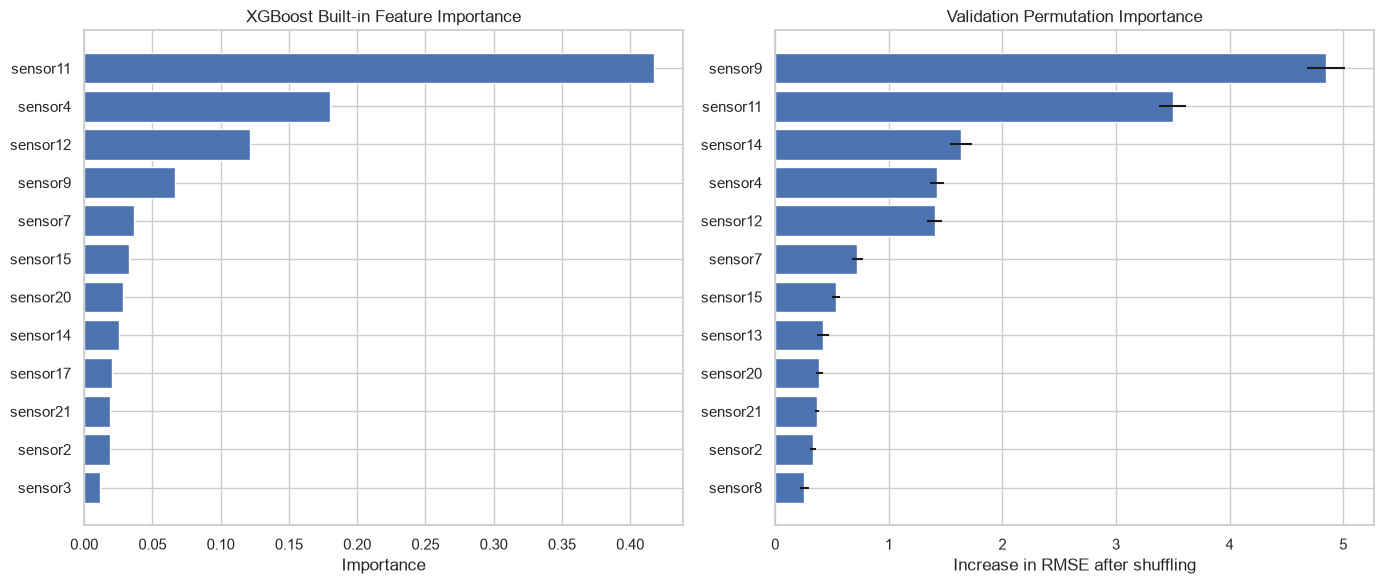

,Feature,Permutation_Importance,Permutation_SD
9,sensor9,4.8529,0.1672
10,sensor11,3.4974,0.1171
13,sensor14,1.6330,0.0965
5,sensor4,1.4242,0.0657
11,sensor12,1.4063,0.0656
7,sensor7,0.7240,0.0480
14,sensor15,0.5361,0.0382
12,sensor13,0.4177,0.0517
16,sensor20,0.3887,0.0307
17,sensor21,0.3669,0.0174


In [92]:
built_in_importance = pd.DataFrame(
    {
        "Feature": feature_columns,
        "XGBoost_Importance": tuned_xgb.feature_importances_,
    }
).sort_values("XGBoost_Importance", ascending=False)

permutation = permutation_importance(
    tuned_xgb,
    X_validation,
    y_validation,
    scoring="neg_root_mean_squared_error",
    n_repeats=10,
    random_state=RANDOM_STATE,
    n_jobs=1,
)
permutation_df = pd.DataFrame(
    {
        "Feature": feature_columns,
        "Permutation_Importance": permutation.importances_mean,
        "Permutation_SD": permutation.importances_std,
    }
).sort_values("Permutation_Importance", ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

top_builtin = built_in_importance.head(12).sort_values(
    "XGBoost_Importance"
)
axes[0].barh(top_builtin["Feature"], top_builtin["XGBoost_Importance"])
axes[0].set_title("XGBoost Built-in Feature Importance")
axes[0].set_xlabel("Importance")

top_permutation = permutation_df.head(12).sort_values(
    "Permutation_Importance"
)
axes[1].barh(
    top_permutation["Feature"],
    top_permutation["Permutation_Importance"],
    xerr=top_permutation["Permutation_SD"],
)
axes[1].set_title("Validation Permutation Importance")
axes[1].set_xlabel("Increase in RMSE after shuffling")

plt.tight_layout()
plt.show()

permutation_df.head(10).round(4)

## 12. Capped and Uncapped RUL Check

The main experiment uses RUL clipped at 125 cycles because that matches Mina's baseline. The second row below compares the same predictions with the original official RUL labels. These are different target definitions, so their metrics should not be mixed in one model ranking.

In [93]:
target_check_df = pd.DataFrame(
    [
        {
            "Target definition": "RUL clipped at 125",
            **regression_metrics(y_test, tuned_test_predictions),
        },
        {
            "Target definition": "Official uncapped RUL",
            **regression_metrics(y_test_uncapped, tuned_test_predictions),
        },
    ]
)
target_check_df.round(3)

,Target definition,RMSE,MAE,R2
0,RUL clipped at 125,16.843,11.614,0.823
1,Official uncapped RUL,17.813,12.684,0.816


## 13. Save My Results

The comparison, predictions, cross-validation results, engine split, and final XGBoost model are saved inside the repository. These files support the final report and allow teammates to review my work.

In [94]:
reports_dir = Path("../reports")
models_dir = Path("../models")
reports_dir.mkdir(exist_ok=True)
models_dir.mkdir(exist_ok=True)

comparison_path = reports_dir / "advanced_ml_model_comparison.csv"
predictions_path = reports_dir / "advanced_ml_test_predictions.csv"
cv_path = reports_dir / "advanced_ml_cv_results.csv"
split_path = reports_dir / "advanced_ml_engine_split.csv"
model_path = models_dir / "tuned_xgboost_fd001.json"

comparison_df.to_csv(comparison_path, index=False)
prediction_df.to_csv(predictions_path, index=False)
cv_summary.to_csv(cv_path, index=False)
pd.DataFrame(
    {
        "engine_id": np.concatenate([train_ids, validation_ids]),
        "partition": (
            ["train"] * len(train_ids)
            + ["validation"] * len(validation_ids)
        ),
    }
).to_csv(split_path, index=False)
tuned_xgb.save_model(model_path)

print("Saved my advanced ML files:")
for output_path in [
    comparison_path,
    predictions_path,
    cv_path,
    split_path,
    model_path,
]:
   print(f"- {output_path}")

Saved my advanced ML files:
- ../reports/advanced_ml_model_comparison.csv
- ../reports/advanced_ml_test_predictions.csv
- ../reports/advanced_ml_cv_results.csv
- ../reports/advanced_ml_engine_split.csv
- ../models/tuned_xgboost_fd001.json


## 14. Conclusion and Limitations

In the verified run, the grid search selected `learning_rate=0.03`, `max_depth=4`, and `n_estimators=200`. Tuned XGBoost produced a test RMSE of 16.843 cycles, test MAE of 11.614 cycles, and test R² of 0.823. Random Forest was the strongest traditional baseline with a test RMSE of 17.044 cycles. Therefore, tuned XGBoost reduced test RMSE by about 0.201 cycles, or 1.18%.

The improvement is positive but small. The initial XGBoost model also produced a slightly lower single-split validation RMSE than the tuned model. For this reason, the result should be described as a modest improvement instead of a major performance gain. The grouped cross-validation process still gives a stronger basis for selecting the final hyperparameters than choosing them from the official test results.

The residual and RUL-range results show where the model made larger errors. The importance charts identify the features that contributed most to the XGBoost predictions.

This experiment has several limitations:

- It uses only FD001, with one operating condition and one HPC fault mode.
- Clipping RUL at 125 changes the target for early engine cycles.
- The tuning result depends on the selected parameter grid and folds.
- Feature importance explains model use, not cause and effect.
- RUL predictions do not automatically create a maintenance schedule.

The model can support maintenance planning, but the team would still need risk thresholds, maintenance capacity, service duration, and cost assumptions.

## References


National Aeronautics and Space Administration. (n.d.). *C-MAPSS jet engine simulated data* [Data set]. NASA Open Data Portal. https://data.nasa.gov/dataset/cmapss-jet-engine-simulated-data

XGBoost developers. (n.d.). *XGBoost Python package*. https://xgboost.readthedocs.io/

### AI Use Disclosure

I used ChatGPT/Codex to help organize the notebook, adapt the XGBoost workflow from classification to regression, check the experimental design, and improve grammar. I reviewed and revised the content, ran the code, examined the visualizations and outputs, and made the final decisions about the explanations and interpretations included in this assignment.